In [1]:

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [2]:

transform = transforms.Compose([transforms.ToTensor()])

trainset = datasets.MNIST('/content/Untitled Folder', train=True, download=True, transform=transform)
testset  = datasets.MNIST('/content/Untitled Folder', train=False, download=True, transform=transform)

trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader  = DataLoader(testset, batch_size=64, shuffle=False)


In [3]:

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(13*13*32, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


In [4]:

def pgd_attack(model, images, labels, eps=0.1, alpha=0.01, iters=3):
    images = images.clone().detach().to(device)
    labels = labels.to(device)

    adv = images.clone().detach()
    adv.requires_grad = True

    for _ in range(iters):
        outputs = model(adv)
        loss = criterion(outputs, labels)
        model.zero_grad()
        loss.backward()

        adv = adv + alpha * adv.grad.sign()
        eta = torch.clamp(adv - images, -eps, eps)
        adv = torch.clamp(images + eta, 0, 1).detach()
        adv.requires_grad = True

    return adv


In [5]:

epochs = 3
eps_train = 0.1

for epoch in range(epochs):
    model.train()
    for i, (x, y) in enumerate(trainloader):
        x, y = x.to(device), y.to(device)

        x_adv = pgd_attack(model, x, y, eps=eps_train)

        optimizer.zero_grad()
        loss = criterion(model(x_adv), y)
        loss.backward()
        optimizer.step()

        if i % 100 == 0:
            print(f"Epoch {epoch+1}, Step {i}, Loss {loss.item():.4f}")

print("Training complete")


Epoch 1, Step 0, Loss 2.3040
Epoch 1, Step 100, Loss 0.3025
Epoch 1, Step 200, Loss 0.2509
Epoch 1, Step 300, Loss 0.2429
Epoch 1, Step 400, Loss 0.1421
Epoch 1, Step 500, Loss 0.2177
Epoch 1, Step 600, Loss 0.2030
Epoch 1, Step 700, Loss 0.1317
Epoch 1, Step 800, Loss 0.2715
Epoch 1, Step 900, Loss 0.1335
Epoch 2, Step 0, Loss 0.1584
Epoch 2, Step 100, Loss 0.1997
Epoch 2, Step 200, Loss 0.3016
Epoch 2, Step 300, Loss 0.1033
Epoch 2, Step 400, Loss 0.0696
Epoch 2, Step 500, Loss 0.1167
Epoch 2, Step 600, Loss 0.0840
Epoch 2, Step 700, Loss 0.2467
Epoch 2, Step 800, Loss 0.1459
Epoch 2, Step 900, Loss 0.1681
Epoch 3, Step 0, Loss 0.2322
Epoch 3, Step 100, Loss 0.1425
Epoch 3, Step 200, Loss 0.1357
Epoch 3, Step 300, Loss 0.0439
Epoch 3, Step 400, Loss 0.1863
Epoch 3, Step 500, Loss 0.0561
Epoch 3, Step 600, Loss 0.0230
Epoch 3, Step 700, Loss 0.0847
Epoch 3, Step 800, Loss 0.0514
Epoch 3, Step 900, Loss 0.0467
Training complete


In [6]:

def evaluate(loader, attack=False, eps=0.1, max_batches=10):
    model.eval()
    correct = total = 0

    for i, (x, y) in enumerate(loader):
        if i >= max_batches:
            break

        x, y = x.to(device), y.to(device)
        if attack:
            x = pgd_attack(model, x, y, eps=eps)

        with torch.no_grad():
            preds = model(x).argmax(1)

        correct += (preds == y).sum().item()
        total += y.size(0)

    return 100 * correct / total


Epsilon 0.05: Accuracy 96.56%
Epsilon 0.1: Accuracy 96.56%
Epsilon 0.2: Accuracy 96.56%
Epsilon 0.3: Accuracy 96.56%


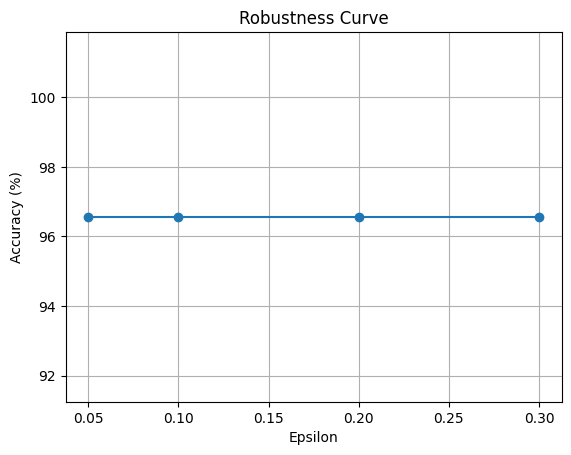

In [7]:

epsilons = [0.05, 0.1, 0.2, 0.3]
accs = []

for eps in epsilons:
    acc = evaluate(testloader, attack=True, eps=eps)
    accs.append(acc)
    print(f"Epsilon {eps}: Accuracy {acc:.2f}%")

plt.plot(epsilons, accs, marker='o')
plt.xlabel("Epsilon")
plt.ylabel("Accuracy (%)")
plt.title("Robustness Curve")
plt.grid(True)
plt.show()


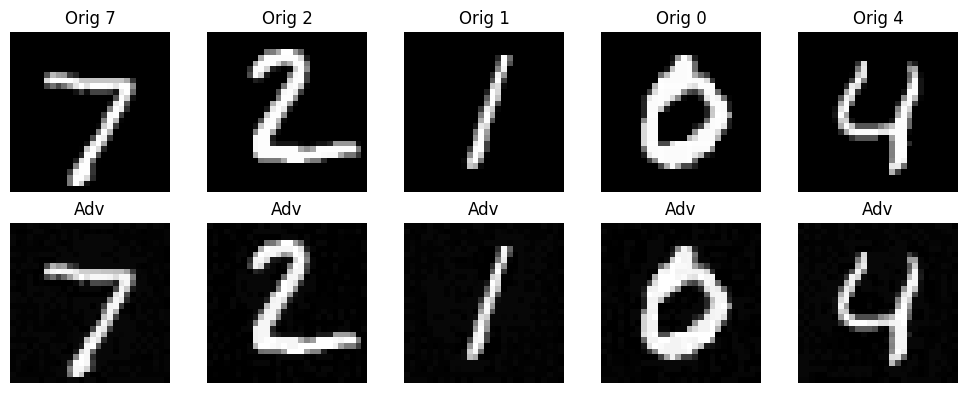

In [8]:

%matplotlib inline

def visualize_adversarial(x, x_adv, y, n=5):
    x = x.detach().cpu()
    x_adv = x_adv.detach().cpu()
    y = y.detach().cpu()

    fig, axes = plt.subplots(2, n, figsize=(10,4))
    for i in range(n):
        axes[0, i].imshow(x[i].squeeze(), cmap='gray')
        axes[0, i].set_title(f"Orig {y[i].item()}")
        axes[0, i].axis('off')

        axes[1, i].imshow(x_adv[i].squeeze(), cmap='gray')
        axes[1, i].set_title("Adv")
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()


x, y = next(iter(testloader))
x, y = x.to(device), y.to(device)
x_adv = pgd_attack(model, x, y, eps=0.3)

visualize_adversarial(x, x_adv, y)



